In [9]:
# =========================
# 1) IMPORTS
# =========================
from google.colab import files
import zipfile
import io
import os
import pandas as pd
import logging

In [10]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

In [13]:
logger.info("Uploading file...")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded!")

logger.info(f"Uploaded files: {list(uploaded.keys())}")

Saving archive (2).zip to archive (2) (1).zip


In [14]:
EXTRACT_PATH = "data"

os.makedirs(EXTRACT_PATH, exist_ok=True)


def safe_extract_zip(uploaded_file_bytes, extract_to="data"):
    try:
        with zipfile.ZipFile(io.BytesIO(uploaded_file_bytes)) as z:

            # güvenlik: zip slip protection
            for file in z.namelist():
                if ".." in file or file.startswith("/"):
                    raise ValueError(f"Unsafe file path detected: {file}")

            z.extractall(extract_to)

        logger.info(f"Extraction completed → {extract_to}")

    except zipfile.BadZipFile:
        raise ValueError("Invalid ZIP file!")

In [15]:
for filename, filedata in uploaded.items():
    logger.info(f"Processing: {filename}")
    safe_extract_zip(filedata, EXTRACT_PATH)

In [16]:
logger.info("Listing extracted files...")

for root, dirs, files_list in os.walk(EXTRACT_PATH):
    for f in files_list:
        logger.info(os.path.join(root, f))

In [17]:
def load_all_csvs(path="data"):
    dataframes = {}

    for root, _, files_list in os.walk(path):
        for file in files_list:
            if file.endswith(".csv"):
                full_path = os.path.join(root, file)
                try:
                    df = pd.read_csv(full_path)
                    dataframes[file] = df
                    logger.info(f"Loaded CSV: {file} | shape={df.shape}")
                except Exception as e:
                    logger.error(f"Failed to load {file}: {e}")

    return dataframes

In [18]:
datasets = load_all_csvs(EXTRACT_PATH)

print("\nLoaded datasets:")
for name, df in datasets.items():
    print(f"{name} → {df.shape}")


Loaded datasets:
diamonds.csv → (50000, 10)


In [11]:
#kütüphaneleri iç aktarıyoruz
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#veri işleme,görselleştirme ve modelleme için gerkli kütüphaneleri yükledik
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

sns.set_theme()


In [40]:
first_key = list(datasets.keys())[0]
datasets[first_key].head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


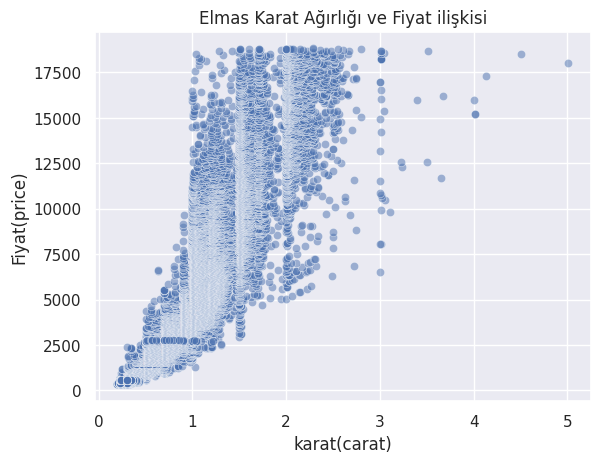

In [41]:
#elmas fiyatlarıyla karat ağırlığı arasındaki ilişkiyi inceliyoruz
sns.scatterplot(x="carat",y="price",data=df,alpha=0.5)
plt.title("Elmas Karat Ağırlığı ve Fiyat ilişkisi")
plt.xlabel("karat(carat)")
plt.ylabel("Fiyat(price)")
plt.show()


In [42]:
#Basit linear regresyon modeli
#carat değişkeni ile fiyat tahmini yapıyoruz
X=df[["carat"]] #bağımsız değişken(2D)
Y = df["price"] #bağımlı değişken(1D)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# =========================
# MODEL TRAINING
# =========================
model = LinearRegression()
model.fit(X_train, y_train)


#Y=W.X+B
print(f"Model Sabiti(b): {model.intercept_:.2f}") #İNTERCEPT SABİT TERİM
print(f"katsayı(w): {model.coef_[0]:.2f}") #coef katsayı demek

Model Sabiti(b): -2258.57
katsayı(w): 7763.78


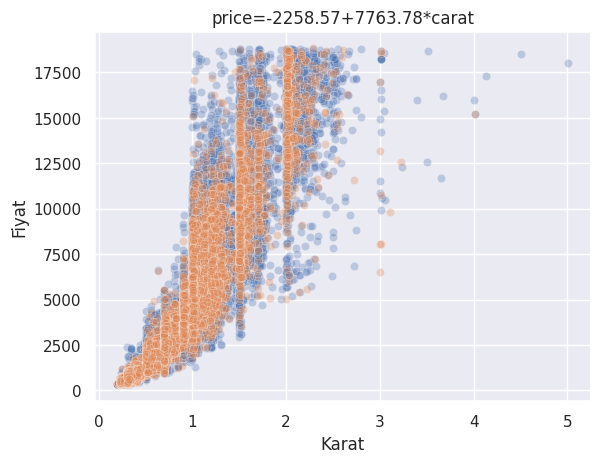

In [43]:
#Regresyon Doğrusunun görselleştirilmesi

#scatter plot(dağılım grafiği) üzerine modelin tahmini ekliyoruz

sns.scatterplot(x=X_train["carat"], y=y_train, alpha=0.3)
sns.scatterplot(x=X_test["carat"], y=y_test, alpha=0.3)
plt.title(f"price={model.intercept_:.2f}+{model.coef_[0]:.2f}*carat")
plt.xlabel("Karat")
plt.ylabel("Fiyat")
plt.show()



In [38]:
#model perfomans değerlendirmesi
y_pred = model.predict(X_test)

#pred=predict
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error(MSE):{mse:.2f}")
print(f"Root Mean Squared Error(RMSE):{rmse:.2f}")
print(f"R^2 Score:{r2:.2f}")


Mean Squared Error(MSE):2275502.66
Root Mean Squared Error(RMSE):1508.48
R^2 Score:0.85


In [39]:
import numpy as np

input_data = pd.DataFrame([[1.5]], columns=["carat"])
tahmini_fiyat = model.predict(input_data)[0]
print(f"1.5 karat elmas için tahmini fiyat: {tahmini_fiyat:}")


1.5 karat elmas için tahmini fiyat: 9387.097464095
